In [160]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from iminuit import Minuit
from iminuit import cost
from scipy import stats
from scipy.optimize import curve_fit

plt.rcParams['font.family'] = 'monospace'

#### Functions

In [161]:
def lin_to_dB(x):
    return 20 * np.log10(x)

def deg_to_rad(deg):
    return (np.pi / 180) * deg

def rms_to_amp(rms):
    return rms * np.sqrt(2)


#### Experiment 1 - plots

In [162]:
# Raw data
df1 = pd.read_csv("bandpass_characterization_data.csv", delimiter=",")

freq = df1["freq_Hz"].to_numpy()
print(freq[-1])
vol_max = df1["Vmax_V"].to_numpy()
vol_min = df1["Vmin_V"].to_numpy()
phase_deg = df1["phase_deg"].to_numpy()

40000.0


In [163]:
# Array conversions
A_ref = 5
amp = (vol_max - vol_min) / 2
offset = (vol_max + vol_min) / 2
amp_dB = lin_to_dB(amp)
#phase_rad = np.unwrap(deg_to_rad(phase_deg)) # Unwrapped

def phase_unwrapper(phase_deg):
    diffs = np.diff(phase_deg)
    jumps = np.where(np.abs(diffs) > 180)[0]
    unwrapped = phase_deg.copy()
    for jump in jumps:
        if diffs[jump] > 0:
            unwrapped[jump + 1:] -= 360
        else:
            unwrapped[jump + 1:] += 360
    return unwrapped

phase_deg_unwrapped = phase_unwrapper(phase_deg)

In [164]:
print("Frequencies (Hz):", freq)
print("Amplitudes (V):", amp)
print("Amplitudes (dB):", amp_dB)

Frequencies (Hz): [  500.   750.  1000.  1500.  2000.  3000.  4000.  5000.  6000.  7000.
  8000.  9000. 10000. 11000. 12000. 13000. 14000. 15000. 16000. 17000.
 18000. 19000. 20000. 22000. 24000. 26000. 30000. 40000.]
Amplitudes (V): [0.022  0.042  0.0655 0.097  0.1115 0.2075 0.274  0.3865 0.5265 0.686
 0.8505 1.005  1.1115 1.1415 1.1105 1.021  0.9175 0.817  0.7265 0.6555
 0.592  0.5525 0.5    0.436  0.383  0.3415 0.279  0.197 ]
Amplitudes (dB): [-33.15154638 -27.53501419 -23.675174   -20.26456531 -19.05450265
 -13.65963798 -11.24498874  -8.25701003  -5.57203249  -3.27351769
  -1.40651364   0.04332124   0.91818934   1.14951832   0.91037126
   0.18051484  -0.74787854  -1.75555887  -2.77528763  -3.66854608
  -4.55356587  -5.15335435  -6.02059991  -7.21027021  -8.33602452
  -9.33218584 -11.08791593 -14.11067548]


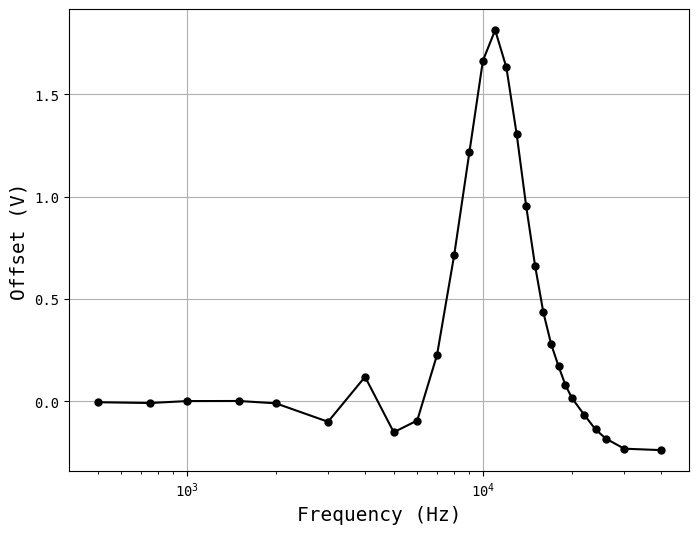

In [165]:
# Plot the phase in degrees, but unwrapped
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(freq, offset, 'o-', ms = 5, color = 'k')
ax.set_xscale('log')
ax.set_xlabel('Frequency (Hz)', fontsize=14)
ax.set_ylabel('Offset (V)', fontsize=14)


ax.grid(True)
plt.show()

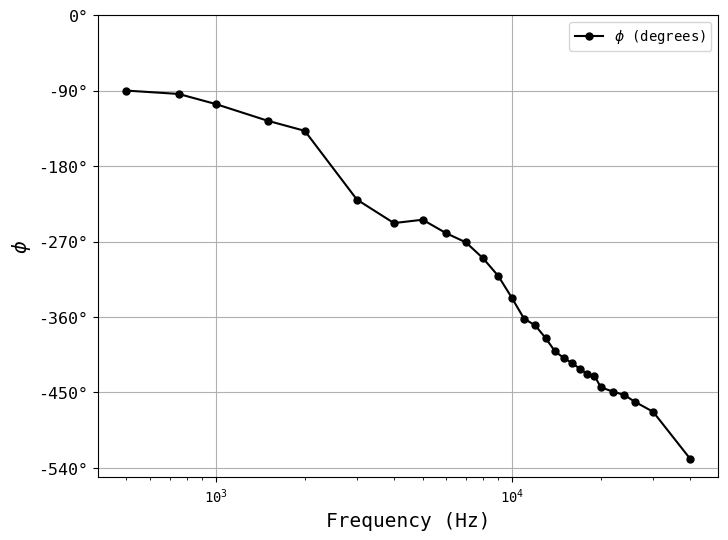

In [166]:

# Plot the phase in degrees, but unwrapped
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(freq, phase_deg_unwrapped, 'o-', ms = 5, color = 'k', label=r'$\phi$ (degrees)')
ax.set_xscale('log')
ax.set_xlabel('Frequency (Hz)', fontsize=14)
ax.set_ylabel(r'$\phi$', fontsize=14)

#Set yticks to be every 90 degrees, and y-tick labels in degrees
ax.set_yticks(np.arange(-540, 90, 90))
ax.set_yticklabels([f"{int(tick)}°" for tick in np.arange(-540, 90, 90)], fontsize=12)

ax.grid(True)
ax.legend()
plt.show()

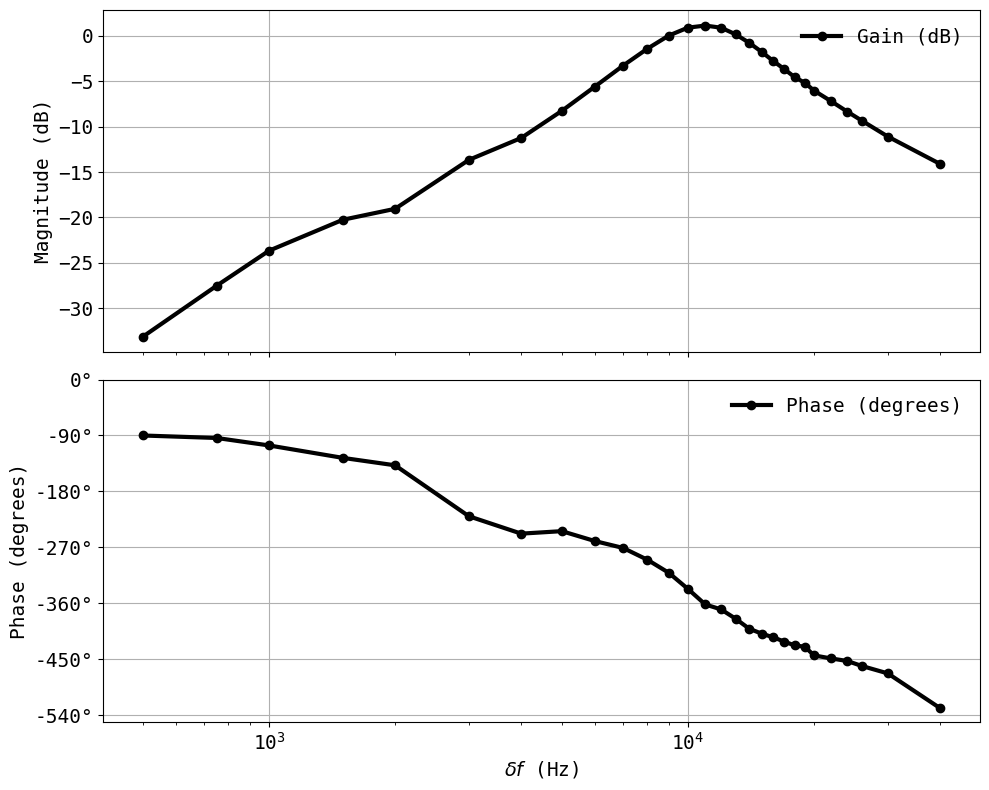

In [167]:
# Plotting amplitude dB

fig, ax = plt.subplots(2,1, figsize=(10, 8), sharex=True)

ax[1].plot(freq, phase_deg_unwrapped, 'o-', linewidth = 3, ms = 6, color = 'k', label=r'Phase (degrees)')
ax[1].set_xscale('log')
#ax[1].set_xlabel('Frequency (Hz)', fontsize=14)
ax[1].set_ylabel(r'Phase (degrees)', fontsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)

#Set yticks to be every 90 degrees, and y-tick labels in degrees
ax[1].set_yticks(np.arange(-540, 90, 90))
ax[1].set_yticklabels([f"{int(tick)}°" for tick in np.arange(-540, 90, 90)], fontsize=14)

ax[1].grid(True)
ax[1].legend(fontsize = 14, frameon = False)

ax[0].plot(freq, amp_dB, 'o-', linewidth = 3, ms = 6, color='k', label = 'Gain (dB)')
ax[1].set_xlabel(r"$\delta f$ (Hz)", fontsize=14)
ax[0].set_ylabel(r"Magnitude (dB)", fontsize=14)
ax[0].set_xscale('log')
ax[0].grid(True)
ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[0].legend(fontsize =14, frameon = False)

plt.tight_layout()
plt.show()

In [168]:
def gain_model(f, f_minus, f_plus, G, k):
    num = np.abs(G)*(f/f_minus)**2
    den = ((1+(f/f_minus)**2) * (1+(f/f_plus)**2))
    H = num/den
    return 20 *np.log10(H) + k

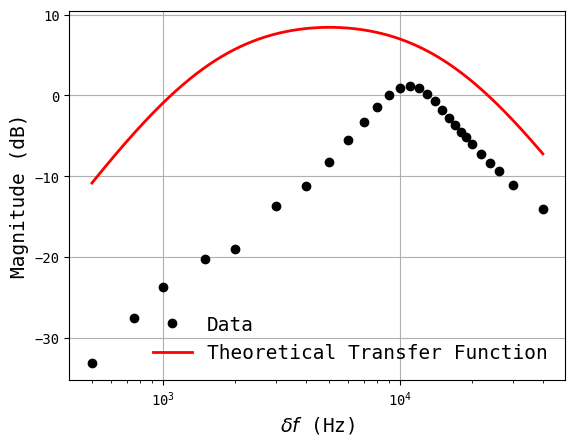

In [169]:
plt.plot(freq, amp_dB, 'o', ms = 6, color='k', label='Data')
fc1_theory = 1.59e3
fc2_theory = 15.9e3
xvals = np.logspace(np.log10(freq[0]), np.log10(freq[-1]), 1000)
G_theory = -1010
yvals_theory = gain_model(xvals, fc1_theory, fc2_theory, G_theory, 0)-50
plt.plot(xvals, yvals_theory, linestyle='-', linewidth = 2, color='r', label='Theoretical Transfer Function')
plt.xscale('log')
plt.xlabel(r"$\delta f$ (Hz)", fontsize=14)
plt.ylabel(r"Magnitude (dB)", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14, frameon=False)

In [170]:
amp_er = 0.02 # Error from, stage 5 DC signal noise measurements (standard deviation of residuals)
amp_dB_err = (20 / np.log(10)) * (amp_er / amp)
print("Amplitude errors in dB:", amp_dB_err)

Amplitude errors in dB: [7.89626331 4.13613792 2.65218004 1.79090508 1.55800711 0.83719418
 0.63400654 0.44946389 0.32994832 0.25323293 0.20425372 0.17285353
 0.15629131 0.15218379 0.15643205 0.17014475 0.18933819 0.21262888
 0.23911603 0.2650157  0.29344222 0.31442134 0.34743559 0.3984353
 0.45357126 0.50869046 0.62264442 0.88181621]


In [171]:
# def gain_model(f, f_minus, f_plus, G, k):
#     num = np.abs(G)*(f/f_minus)**2
#     den = ((1+(f/f_minus)**2) * (1+(f/f_plus)**2))
#     H = num/den
#     return 20 *np.log10(H) + k

def gain_modelV2(f, f_minus, f_delta, G):
    f_plus = f_minus + f_delta
    num = np.abs(G) * (f/f_minus)**2
    den = (1 + (f/f_minus)**2) * (1 + (f/f_plus)**2)
    H = num/den
    return 20*np.log10(num/den)

y_errs = amp_dB_err

#Fit with minuit chi2: 
x0 = 10
x1 = -10

mfit = cost.LeastSquares(freq[x0:x1], amp_dB[x0:x1], y_errs[x0:x1], gain_modelV2)
# Initial guesses: f_minus = 1kHz, f_delta = 10kHz, G = 1, k = 0
minuit_bandpass = Minuit(mfit, f_minus=2000, f_delta=10000, G=-1010)
minuit_bandpass.limits['f_minus'] = (1000, 7500)  # Limit f_minus to be between 1kHz and 10kHz
minuit_bandpass.limits['f_delta'] = (1, 200000)  # Limit f_plus to be between 10kHz and 200kHz
minuit_bandpass.limits['G'] = (None, 0)  # strictly negative, no upper bound
minuit_bandpass.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 130 (χ²/ndof = 26.0)       │              Nfcn = 324              │
│ EDM = 2.3e-05 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name    │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼─────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ f_minus │  7.50e3   │  0.13e3   │            │            │  1000   │  7500   │       │
│ 1 │ f_delta │   6.8e3   │   0.6e3   │            │            │    1    │ 200000  │       │
│ 2 │ G       │   -2.44   │   0.08    │            │            │         │    0    │       │
└───┴─────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────────┬────────────────────────────┐
│         │  f_minus  f_delta        G │
├─────────┼────────────────────────────┤
│ f_minus │   0.0141   -0.269   -0.000 │
│ f_delta │   -0.269 3.31e+05   43.044 │
│       G │   -0.000   43.044   0.0059 │
└─────────┴────────────────────────────┘

In [172]:
chi2 = minuit_bandpass.fval
ndof = len(freq) - len(minuit_bandpass.values)
print(f"Chi-squared: {chi2:.2f}, Degrees of freedom: {ndof}, Reduced chi-squared: {chi2/ndof:.2f}")

Chi-squared: 129.96, Degrees of freedom: 25, Reduced chi-squared: 5.20


Fitted parameters:
f_minus = 7500 Hz ± 130 Hz
f_plus = 14346 Hz ± 589 Hz
G = -2.44 ± 0.08 dB


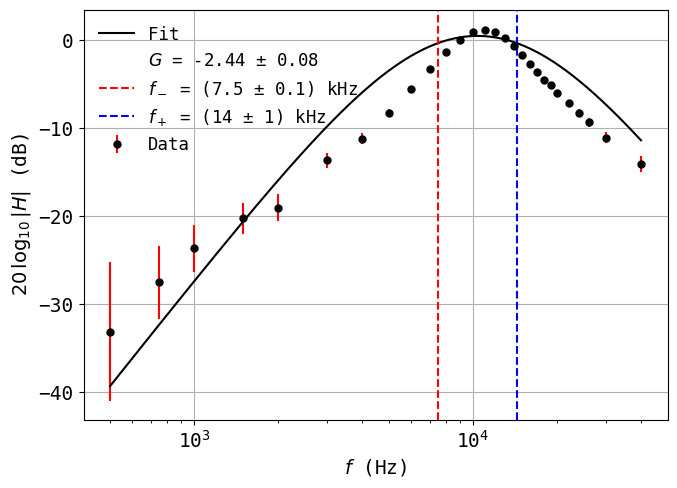

In [173]:
params = minuit_bandpass.values
errors = minuit_bandpass.errors
f_minus = params['f_minus']
f_plus = params['f_minus'] + params['f_delta']
gain = params['G']
f_plus_error = np.sqrt(errors['f_minus']**2 + errors['f_delta']**2)
print("Fitted parameters:")
print(f"f_minus = {params['f_minus']:.0f} Hz ± {errors['f_minus']:.0f} Hz")
print(f"f_plus = {f_plus:.0f} Hz ± {f_plus_error:.0f} Hz")
print(f"G = {params['G']:.2f} ± {errors['G']:.2f} dB")
#plot:
f_linspace = np.linspace(np.min(freq), np.max(freq), 1000)
func_values = gain_modelV2(f_linspace, *params)


AXES_RECT = [0.15, 0.13, 0.73, 0.82]  # [left, bottom, width, height]
fig = plt.figure(figsize=(8, 5))
ax = fig.add_axes(AXES_RECT)
ax.errorbar(freq, amp_dB, yerr=y_errs, fmt='o', ms = 5, color='k', ecolor='r', label='Data')
ax.plot(f_linspace, func_values, linestyle='-', color='k', label=f'Fit')
ax.plot([], [], ' ', label=f'$G$ = {gain:.2f} ± {errors["G"]:.2f}')
ax.axvline(f_minus, color='r', linestyle='--', label=f'$f_-$ = ({round(f_minus, -2)/1000:.1f} ± {round(errors["f_minus"], -2)/1000:.1f}) kHz')
ax.axvline(f_plus, color='b', linestyle='--', label=f'$f_+$ = ({round(f_plus, -2)/1000:.0f} ± {round(f_plus_error, -2)/1000:.0f}) kHz')

ax.set_xlabel(r"$f$ (Hz)", fontsize=14)
ax.set_ylabel(r"$20 \,\log_{10}|H|$ (dB)", fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xscale('log')
ax.grid(True)
ax.legend(loc = 'upper left', frameon = False, fontsize = 12.5);
fig.subplots_adjust(left=0.12, right=0.88, bottom=0.12, top=0.95)
plt.savefig('stage13_fit.pdf', dpi=600);